<a href="https://colab.research.google.com/github/Kigunda-lilian/Data_science/blob/main/Copy_of_lec4_notebook_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 5: Data Visualization with Matplotlib and Seaborn  
## Case Study: Understanding Bike Rental Patterns

In data science, once data has been collected and organized, the next step is to explore it in a way that reveals patterns and relationships. Tables and summary statistics are useful, but they do not always make trends or differences easy to see. In this notebook, we will learn how **data visualization** helps us better understand data by using the Bike Sharing dataset as a case study.

This notebook introduces **Matplotlib** and **Seaborn**, two important Python libraries for visualization. Through examples, we will learn how to create common plots such as line plots, histograms, boxplots, scatter plots, and heatmaps, and how to use them to communicate insights clearly. Since visualization is a key part of exploratory data analysis, this chapter will provide a practical foundation for later data analysis and modeling.

## Practice Question 5.3.1.1 — Monthly Rental Trend

Daily data can be noisy and difficult to interpret visually. Instead of plotting daily rentals, create a line plot showing
**average monthly rental demand**.

Steps:

1. Convert the date to a year–month period.
2. Group the data by year–month.
3. Compute the average total rentals for each month.
4. Plot the monthly averages as a line plot.

After plotting, answer:

- Which months have the highest demand?
- Is the seasonal pattern clearer than in the daily plot?
- Why might monthly aggregation be useful for managers?

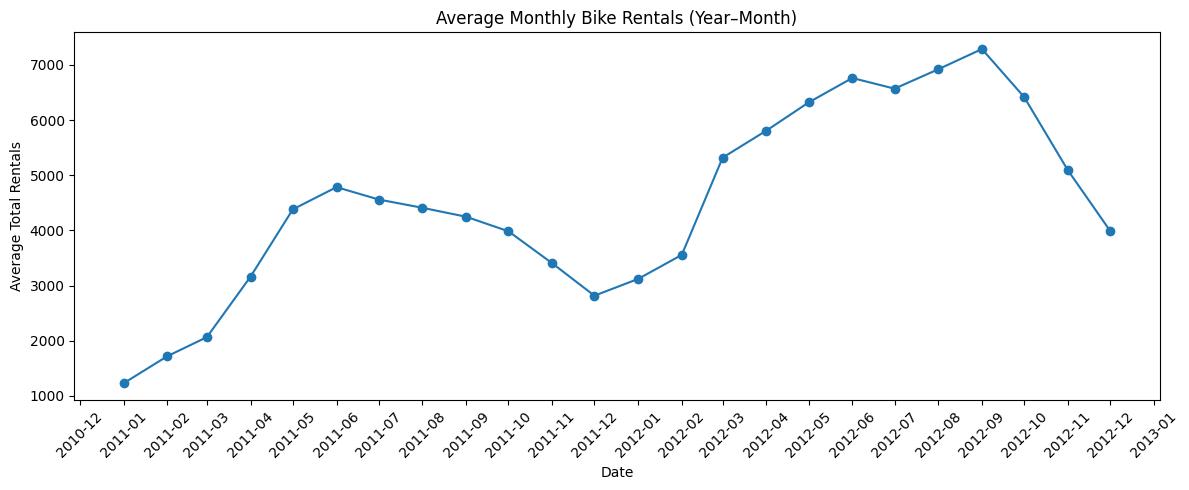

In [ ]:
# Solution

import matplotlib.dates as mdates

# Ensure datetime format
df["dteday"] = pd.to_datetime(df["dteday"])

# Create year-month variable
df["year_month"] = df["dteday"].dt.to_period("M")

# Group by year-month and compute average rentals
monthly_avg = df.groupby("year_month")["cnt"].mean()

# Convert PeriodIndex back to timestamp for plotting
monthly_avg.index = monthly_avg.index.to_timestamp()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"   # Add point markers
)

plt.title("Average Monthly Bike Rentals (Year–Month)")
plt.xlabel("Date")
plt.ylabel("Average Total Rentals")

# Monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Practice Question 5.3.1.2 — Rolling Average Trend

Daily rentals fluctuate substantially.

Create a line plot showing:

- The original daily rental counts
- A 7-day moving average of rentals

Plot both on the same figure.

After plotting, answer:

- Does the moving average make the trend clearer?
- What information is lost when smoothing the data?
- When would a manager prefer the smoothed version?

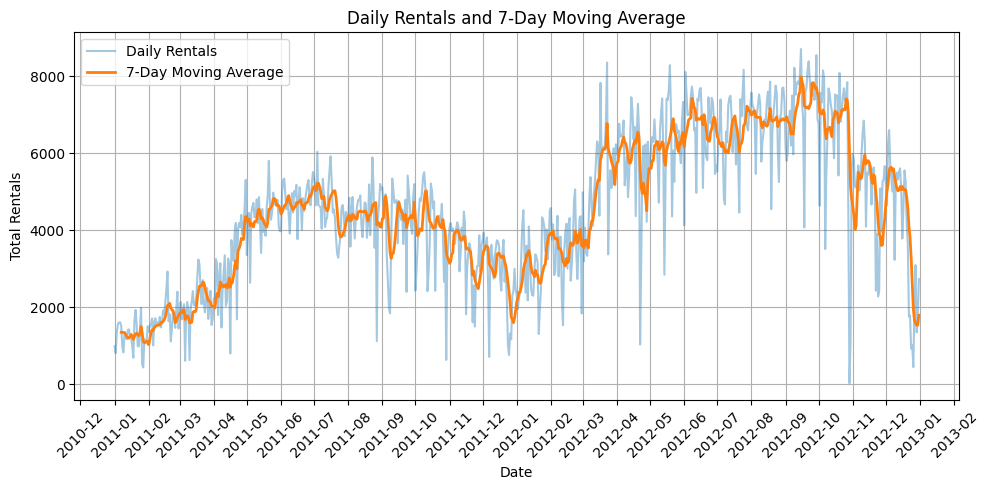

In [ ]:
# Solution

# Calculate 7-day moving average
df["rolling_7"] = df["cnt"].rolling(window=7).mean()

plt.figure(figsize=(10, 5))

plt.plot(df["dteday"], df["cnt"], alpha=0.4, label="Daily Rentals")
plt.plot(df["dteday"], df["rolling_7"], linewidth=2, label="7-Day Moving Average")

plt.title("Daily Rentals and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Total Rentals")

# Monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Practice Question 5.3.2.1

Using the bike dataset:

1. Plot a histogram of daily rental counts (`df["cnt"]`) using:
   - 10 bins
   - 30 bins

2. Compare the two graphs:
   - How does changing the number of bins affect the appearance?
   - Which version better represents the distribution?

3. Based on the histogram:
   - Is the distribution symmetric or skewed?
   - Do extreme rental days appear common or rare?

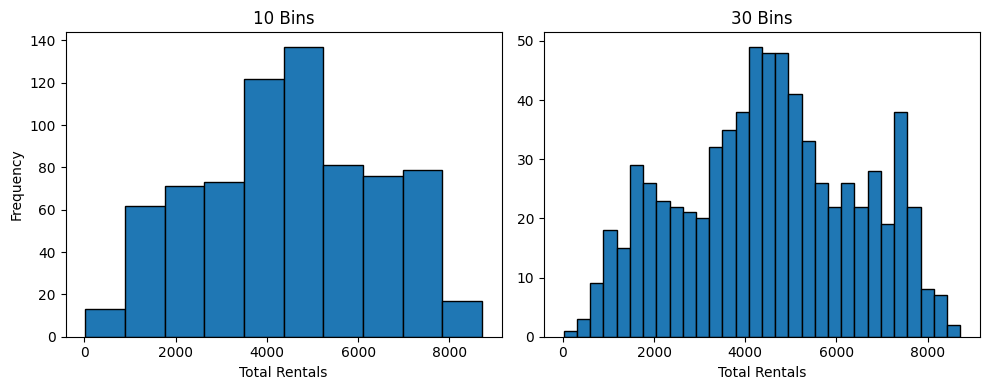

In [ ]:
#Solution
plt.figure(figsize=(10, 4))

# 10 bins
plt.subplot(1, 2, 1)
plt.hist(df["cnt"], bins=10, edgecolor='black')
plt.title("10 Bins")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")

# 30 bins
plt.subplot(1, 2, 2)
plt.hist(df["cnt"], bins=30, edgecolor='black')
plt.title("30 Bins")
plt.xlabel("Total Rentals")

plt.tight_layout()
plt.show()

## Practice Question 5.3.2.2

Plot separate histograms for:

- Temperature (`df["temp"]`)
- Total rentals (`df["cnt"]`)

Display them using `plt.subplot()` in a 1×2 layout.

Then answer:

1. Which variable appears more symmetric?
2. Which variable shows more variability?
3. Which variable appears closer to a normal distribution?

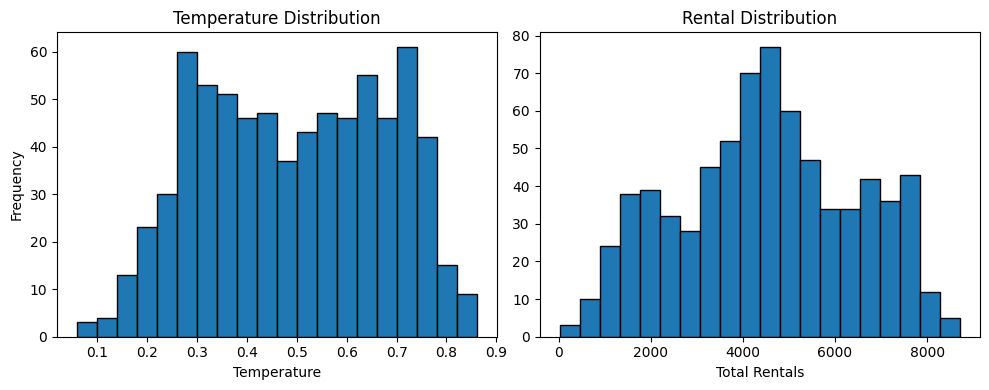

In [ ]:
#Solution
plt.figure(figsize=(10, 4))

# Temperature distribution
plt.subplot(1, 2, 1)
plt.hist(df["temp"], bins=20, edgecolor='black')
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

# Rental distribution
plt.subplot(1, 2, 2)
plt.hist(df["cnt"], bins=20, edgecolor='black')
plt.title("Rental Distribution")
plt.xlabel("Total Rentals")

plt.tight_layout()
plt.show()

## Practice Question 5.3.2.3 — Weekday vs. Weekend Comparison

Create separate histograms of total rentals (`df["cnt"]`) for:

- Weekdays only
- Weekends only

(Hint: Use the `workingday` column.)

Display them side by side using `plt.subplot()`.

Then analyze:

1. Which group has higher rental concentration?
2. Do weekends show more extreme high-rental days?
3. Is the distribution shape similar or different?

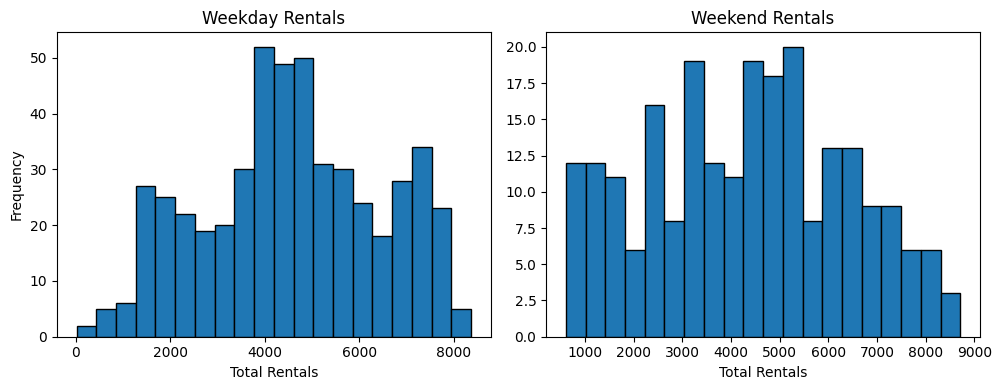

In [ ]:
# Solution
weekday_rentals = df[df["workingday"] == 1]["cnt"]
weekend_rentals = df[df["workingday"] == 0]["cnt"]

plt.figure(figsize=(10, 4))

# Weekdays
plt.subplot(1, 2, 1)
plt.hist(weekday_rentals, bins=20, edgecolor='black')
plt.title("Weekday Rentals")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")

# Weekends
plt.subplot(1, 2, 2)
plt.hist(weekend_rentals, bins=20, edgecolor='black')
plt.title("Weekend Rentals")
plt.xlabel("Total Rentals")

plt.tight_layout()
plt.show()

### Practice Question 5.3.3.1

Create a boxplot of temperature (`df["temp"]`).

1. Is temperature distribution symmetric?
2. Are there noticeable outliers?
3. Compare it visually to the rental boxplot.

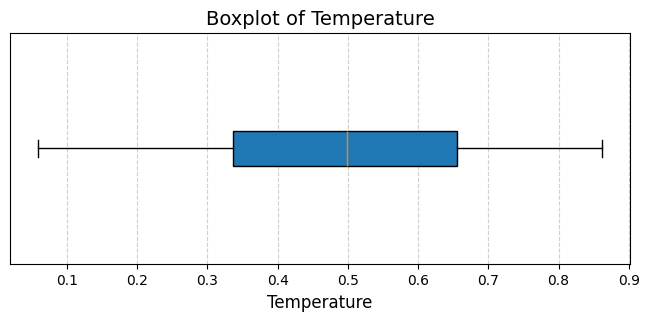

In [ ]:
# Solution
plt.figure(figsize=(8, 3))

plt.boxplot(df["temp"],
            vert=False,
            patch_artist=True)

plt.title("Boxplot of Temperature", fontsize=14)
plt.xlabel("Temperature", fontsize=12)

plt.yticks([])
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

### Practice Question 5.3.3.2

Create separate boxplots for:

- Weekday rentals (`workingday == 1`)
- Weekend rentals (`workingday == 0`)

Display them vertically for comparison.

1. Which group has a higher median?
2. Which group shows greater variability?
3. Are outliers more common in one group?

/tmp/ipykernel_1854/649926721.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weekday, weekend],


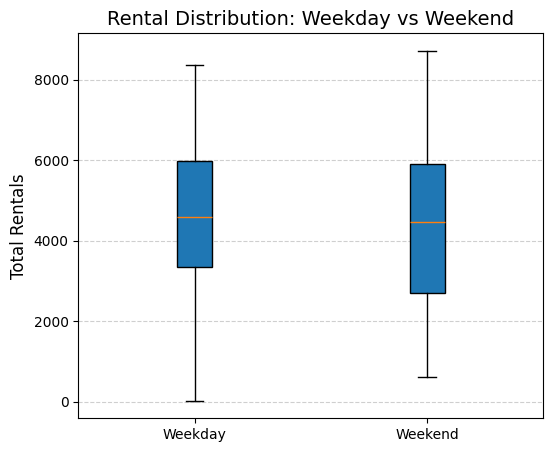

In [ ]:
# Solution
weekday = df[df["workingday"] == 1]["cnt"]
weekend = df[df["workingday"] == 0]["cnt"]

plt.figure(figsize=(6, 5))

plt.boxplot([weekday, weekend],
            labels=["Weekday", "Weekend"],
            patch_artist=True)

plt.title("Rental Distribution: Weekday vs Weekend", fontsize=14)
plt.ylabel("Total Rentals", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

## Practice Question 5.4.1.1 — Humidity and Rental Demand

Create a scatter plot showing the relationship between:

- Humidity (`hum`)
- Total rentals (`cnt`)

Add:
- A clear title
- Axis labels
- Transparency (`alpha`) to improve readability

After plotting, answer:

- Does humidity appear positively or negatively related to rentals?
- Is the relationship strong or weak?
- Do you observe any unusual clusters or patterns?

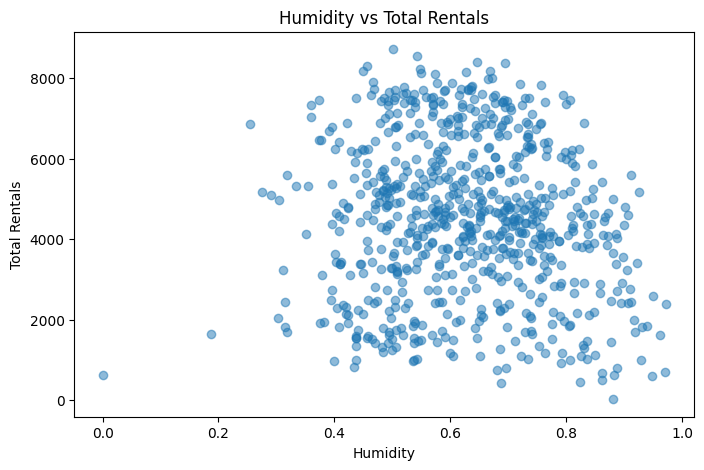

In [ ]:
# Solution

plt.figure(figsize=(8, 5))

plt.scatter(df["hum"], df["cnt"], alpha=0.5)

plt.title("Humidity vs Total Rentals")
plt.xlabel("Humidity")
plt.ylabel("Total Rentals")

plt.show()

## Practice Question 5.4.1.2 — Temperature and Casual Users

Create a scatter plot using:

- Temperature (`temp`) on the x-axis
- Casual rentals (`casual`) on the y-axis

Answer:

- Does temperature affect casual users differently than total demand?
- Would you describe the relationship as strong, moderate, or weak?

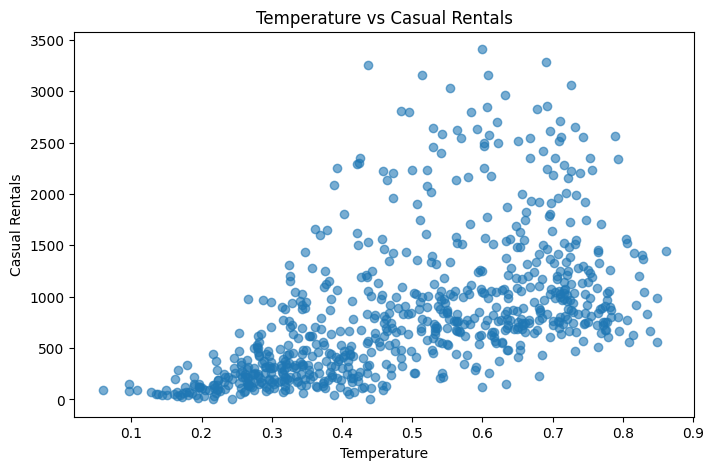

In [ ]:
# Solution

plt.figure(figsize=(8, 5))

plt.scatter(df["temp"], df["casual"], alpha=0.6)

plt.title("Temperature vs Casual Rentals")
plt.xlabel("Temperature")
plt.ylabel("Casual Rentals")

plt.show()

### Practice Question 5.4.2.1

Create a bubble chart where:

- X-axis → Temperature (`temp`)
- Y-axis → Total rentals (`cnt`)
- Bubble size → Humidity (`hum`)

1. Does high humidity appear to reduce rentals?
2. Is the relationship between temperature and rentals still visible?

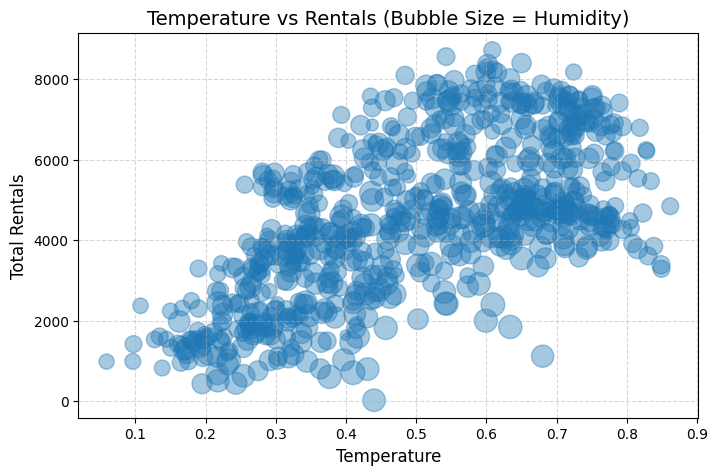

In [ ]:
# Solution
plt.figure(figsize=(8, 5))

bubble_size = df["hum"] *300

plt.scatter(df["temp"],
            df["cnt"],
            s=bubble_size,
            alpha=0.4)

plt.title("Temperature vs Rentals (Bubble Size = Humidity)", fontsize=14)
plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Total Rentals", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Practice Question 5.5.1.1

Create a bar chart showing the **average temperature by season**.

1. Which season has the highest average temperature?
2. Does the temperature pattern align with rental patterns?

/tmp/ipykernel_1854/1563256828.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Season")["temp"]


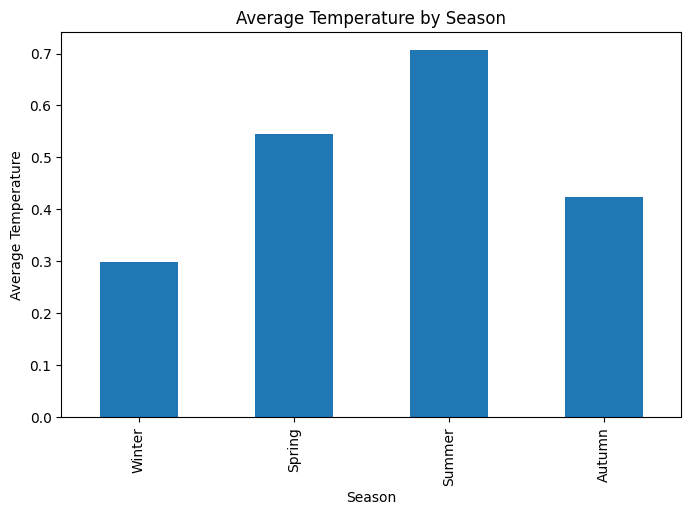

Season with highest average temperature: Summer


In [ ]:
# Solution

season_map = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Autumn"}

temp_avg = (
    df.assign(
        Season=pd.Categorical(
            df["season"].map(season_map),
            categories=season_map.values(),
            ordered=True
        )
    )
    .groupby("Season")["temp"]
    .mean()
)

temp_avg.plot(kind="bar", figsize=(8,5), title="Average Temperature by Season")

plt.xlabel("Season")
plt.ylabel("Average Temperature")
plt.show()

print("Season with highest average temperature:", temp_avg.idxmax())

### Practice Question 5.5.1.2

Create a bar chart showing the **total rentals by month**.

1. Which month has the highest total rentals?
2. Is the pattern consistent with seasonal trends observed earlier?

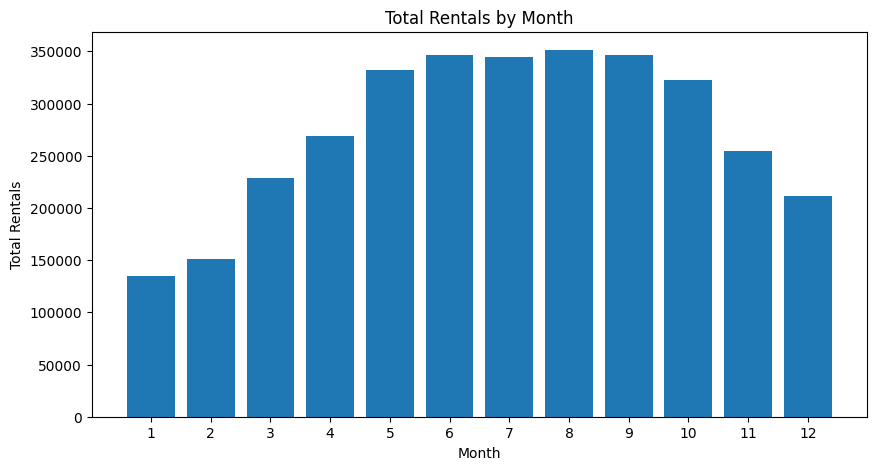

Month with highest total rentals: 8


In [ ]:
# Solution
monthly_total = df.groupby("mnth")["cnt"].sum()

plt.figure(figsize=(10, 5))

plt.bar(monthly_total.index, monthly_total.values, align='center')

plt.title("Total Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Total Rentals")

plt.xticks(monthly_total.index)

plt.show()

print("Month with highest total rentals:", monthly_total.idxmax())

### Practice Question 5.5.3.1

Create a stacked bar chart showing the **average casual and registered rentals**
by **working day (0 = No, 1 = Yes)**.

Steps:

1. Group the dataset by `workingday`.
2. Compute the average of `casual` and `registered`.
3. Create a stacked bar chart using `plt.bar()` and the `bottom` argument.
4. Add readable category labels.

After plotting, answer:

- Which user type contributes more on working days?
- Is the composition different on non-working days?

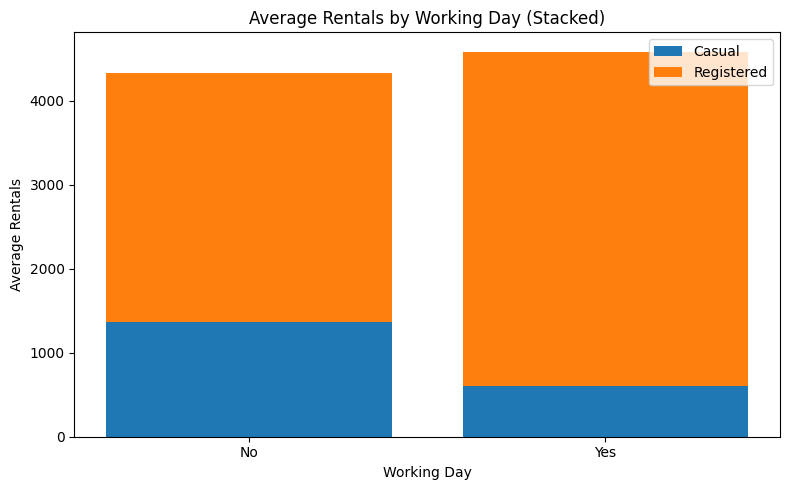

In [ ]:
# Solution

# Step 1: Aggregate data
workingday_avg = df.groupby("workingday")[["casual", "registered"]].mean()

casual_avg = workingday_avg["casual"].values
registered_avg = workingday_avg["registered"].values

# Step 2: X positions
x = np.arange(len(workingday_avg))

plt.figure(figsize=(8, 5))

# Bottom layer
plt.bar(x, casual_avg, label="Casual")

# Stacked layer
plt.bar(x, registered_avg, bottom=casual_avg, label="Registered")

plt.title("Average Rentals by Working Day (Stacked)")
plt.xlabel("Working Day")
plt.ylabel("Average Rentals")

plt.xticks(x, ["No", "Yes"])

plt.legend()
plt.tight_layout()
plt.show()

#### <Practice Question 1>

Plot the graph of $y = 5x + 3$ for $x$ values ranging from $-10$ to $10$.

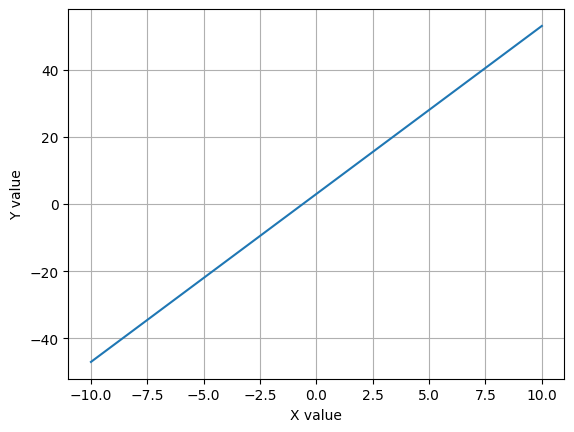

In [ ]:
x = np.linspace(-10, 10, 100)
y = 5 * x + 3

plt.plot(x, y)
plt.xlabel("X value")
plt.ylabel("Y value")
plt.grid(True)

#### <Practice Question 2>

By using `plt.plot()` multiple times, you can plot multiple graphs in the same plot.

Plot the graphs of $y = sin(x)$ and $y = cos(x)$ on the same plot for $x$ values ranging from $-10$ to $10$.

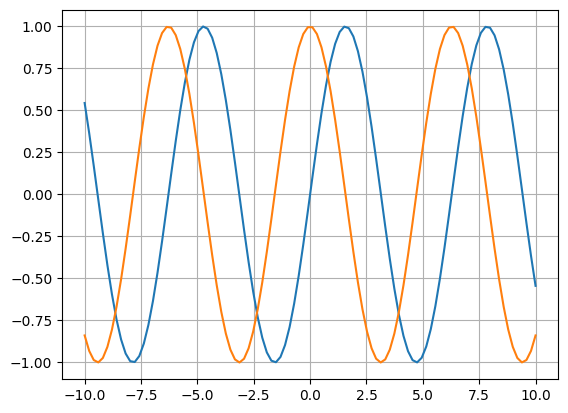

In [ ]:
x = np.linspace(-10, 10,100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.plot(x, y1)
plt.plot(x, y2)

plt.grid(True)